# ROC & AUC — C2 CNN Architectures

End-to-end CNNs that consume the image (plus its counterfactual and/or Grad-CAM saliency map)
directly, rather than the tabular feature vectors used in **`ROC_tabular.ipynb`**.

The runs vary four factors:

| Factor | Levels |
|---|---|
| **Input configuration** | `xi`, `cf`, `xi+cf`, `xi+sal`, `xi+sal+cf` (+ `cf+sal`, kNN only) |
| **Fusion strategy** | `late` (one DenseNet per input, concat pooled embeddings) vs `early` (channel-concat into one DenseNet) |
| **Counterfactual source** | `kNN`-retrieved vs `diffusion`-generated |
| **Counterfactuals per query (K)** | whichever `cf_{K}` directories exist |

`K_FOCUS` is the single K held fixed in §2–§4, so those figures stay three-factor and legible.
§5 varies K; §6 shows all four factors at once.

The tabular **B1** run (C0 probability only, LR) is carried through every figure as a thin
grey dashed reference line, so CNN AUCs stay comparable with the tabular notebook.

Colour encodes exactly one factor per figure; the other factors get linestyle, hatch, or
panel position, so identity is never carried by colour alone.

In [1]:
import itertools
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DISEASE    = 'effusion'   # only 'effusion' has CNN runs
OUTPUT_DIR = 'images/'
RESULTS    = '/zhome/d0/a/221493/thesis/results'
N_FOLDS    = 5

CF_COUNTS = [1, 3]   # every K to load, if present on disk
K_FOCUS   = 3       # the single K that sections 2-4 hold fixed
assert K_FOCUS in CF_COUNTS, 'K_FOCUS must be one of CF_COUNTS'

sys.path.insert(0, '/zhome/d0/a/221493/thesis/code')
from plot_config import PLOT_COLORS, PLOT_LS, PLOT_LW

# ── Palette ───────────────────────────────────────────────────────────────────
CONFIG_COLOR = {                          # factor: input configuration
    'xi':               '#0072B2',        # deep blue
    'cf':               '#009E73',        # teal-green
    'xi+cf':            '#E69F00',        # amber
    'xi+sal':           '#CC79A7',        # mauve
    'xi+sal+cf':        '#9370DB',        # violet
    'xi+sal+cf+scalars': '#B22222',       # firebrick (C0 scalars at the head)
    'cf+sal':           '#56B4E9',        # sky (kNN-only config)
}
SOURCE_COLOR = {'knn': '#0072B2', 'diffusion': '#D55E00'}   # factor: CF source
FUSION_LS    = {'late': '-', 'early': '--'}                 # factor: fusion strategy
FUSION_HATCH = {'late': None, 'early': '//'}
FUSION_ALPHA = {'late': 0.95, 'early': 0.55}
FUSION_MARKER = {'late': 'o', 'early': 's'}

B1_COLOR, B1_LS, B1_LW = PLOT_COLORS['B1'], PLOT_LS['B1'], PLOT_LW['B1']

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'grid.alpha': 0.3,
})
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# ── Where each (source, fusion, config, K) run landed on disk ─────────────────
# Both pipelines write results/<root>/{disease}/{fusion}/{config_dir}/cf_{K}/, but they
# spell the same input tensors differently, so CONFIG_DIRS maps one canonical config
# name onto each pipeline's directory name.
SOURCE_ROOT = {'knn': 'C2_cnn', 'diffusion': 'C2_cnn_diffusion'}
FUSIONS     = ['late', 'early']
SOURCES     = ['knn', 'diffusion']

CONFIG_DIRS = {
    'knn': {           # c2_cnn_all.py / c2_cnn_early_fusion.py
        'xi':                'xi',        # query only                    (single encoder)
        'cf':                'cf',        # counterfactual only           (single)
        'xi+cf':             'dual',      # query + CF                    (dual)
        'xi+sal':            'xi_sal',    # query + its Grad-CAM          (dual)
        'xi+sal+cf':         'dual_sal',  # query + CF + both Grad-CAMs   (quad)
        'xi+sal+cf+scalars': 'dual_sal_scalars',  # quad + C0 scalars at the head
        'cf+sal':            'cf_sal',    # CF + its Grad-CAM             (dual)
    },
    'diffusion': {     # c2_cnn_diffusion.py / c2_cnn_diffusion_early_fusion.py
        'xi':                'xi',
        'cf':                'cf',
        'xi+cf':             'xi_cf',
        'xi+sal':            'xi_saliency',
        'xi+sal+cf':         'xi_saliency_cf',        # query + Grad-CAM + CF  (triple encoder)
        'xi+sal+cf+scalars': 'xi_saliency_cf_scalars',  # triple + C0 scalars at the head
    },
}

# Ordered for plotting: increasing information content, saliency variants after their base.
CONFIG_ORDER = ['xi', 'cf', 'xi+cf', 'xi+sal', 'xi+sal+cf', 'xi+sal+cf+scalars', 'cf+sal']

CONFIG_LABEL = {
    'xi':                r'$x_i$',
    'cf':                r'CF',
    'xi+cf':             r'$x_i$ + CF',
    'xi+sal':            r'$x_i$ + Sal',
    'xi+sal+cf':         r'$x_i$ + Sal + CF',
    'xi+sal+cf+scalars': r'$x_i$ + Sal + CF + C0',
    'cf+sal':            r'CF + Sal',
}

# These configs never read a counterfactual: 'xi' is the query alone, 'xi+sal' the query
# plus its OWN Grad-CAM. Their cf_{K} directories are re-runs of one model, so their lines
# in the K figure are flat by construction and are drawn faint as controls.
K_INVARIANT = {'xi', 'xi+sal'}


def run_path(source, fusion, config, K):
    d = CONFIG_DIRS[source].get(config)
    if d is None:
        return None
    return f'{RESULTS}/{SOURCE_ROOT[source]}/{DISEASE}/{fusion}/{d}/cf_{K}/cv_detailed.json'

In [4]:
# ── Load every (source, fusion, config, K) run ────────────────────────────────
# A run directory without cv_detailed.json is still training; it is listed below and
# excluded from every figure, so a half-finished sweep never reads as a null result.
COMMON_FPR = np.linspace(0, 1, 300)


def summarise(folds):
    """Mean ROC + AUC across CV folds."""
    tprs = [np.interp(COMMON_FPR, f['fpr'], f['tpr']) for f in folds]
    aucs = np.array([f['auc'] for f in folds])
    return {
        'fpr': COMMON_FPR, 'tpr': np.mean(tprs, axis=0), 'std': np.std(tprs, axis=0),
        'auc': aucs.mean(), 'auc_std': aucs.std(), 'aucs': aucs,
        'n_folds': len(folds), 'partial': len(folds) < N_FOLDS,
    }


RUNS, MISSING = {}, []
for source, fusion in itertools.product(SOURCES, FUSIONS):
    for config, K in itertools.product(CONFIG_DIRS[source], CF_COUNTS):
        p = run_path(source, fusion, config, K)
        if p is None:
            continue
        folds = json.load(open(p)) if os.path.exists(p) else None
        if folds:
            RUNS[(source, fusion, config, K)] = summarise(folds)
        else:
            status = 'training' if os.path.isdir(os.path.dirname(p)) else 'not launched'
            MISSING.append(dict(source=source, fusion=fusion, config=config, K=K, status=status))


def b1_reference(K):
    """B1 = C0 probability only, logistic regression, on the kNN folds."""
    p = f'{RESULTS}/C2_custom_corrected/{DISEASE}/cv_results_correct_cf/cf_{K}/cv_detailed.json'
    return summarise(json.load(open(p))['LR']['B1']) if os.path.exists(p) else None


# B1 uses only the C0 probability, so it does not depend on K.
B1 = b1_reference(K_FOCUS)
KS = sorted({k[3] for k in RUNS})

print(f'Loaded {len(RUNS)} runs for {DISEASE} across K = {KS}')
for K in KS:
    print(f'   K={K}: {sum(1 for k in RUNS if k[3] == K):2d} runs')
print('B1 reference: ' + (f"AUC {B1['auc']:.4f} +/- {B1['auc_std']:.4f}" if B1 else 'MISSING'))
print(f'Sections 2-4 hold K = {K_FOCUS}; sections 5-6 vary K.')

if MISSING:
    print(f'\n{len(MISSING)} run(s) not available yet -- excluded from every figure below:')
    print(pd.DataFrame(MISSING).sort_values(['status', 'source', 'fusion', 'K', 'config'])
            .to_string(index=False))

Loaded 52 runs for effusion across K = [1, 3]
   K=1: 26 runs
   K=3: 26 runs
B1 reference: AUC 0.7362 +/- 0.0094
Sections 2-4 hold K = 3; sections 5-6 vary K.


In [5]:
# ── Mean 5-fold test AUC, every run ───────────────────────────────────────────
# '--' = config not defined for that pipeline, or not finished training.
overview = pd.DataFrame(
    {(s, f, K): {CONFIG_LABEL[c]: (f"{RUNS[(s, f, c, K)]['auc']:.4f}"
                                   if (s, f, c, K) in RUNS else '--')
                 for c in CONFIG_ORDER}
     for s in SOURCES for f in FUSIONS for K in KS}
)
overview.index.name = 'config'
print(overview.to_string())

                          knn                         diffusion                        
                         late           early              late           early        
                            1       3       1       3         1       3       1       3
config                                                                                 
$x_i$                  0.8118  0.8126  0.8116  0.8106    0.8155  0.8155  0.8071  0.8071
CF                     0.7193  0.7385  0.7226  0.7444    0.8034  0.8205  0.8115  0.8195
$x_i$ + CF             0.8248  0.8304  0.7700  0.7964    0.8241  0.8276  0.8138  0.8156
$x_i$ + Sal            0.8343  0.8348  0.8269  0.8335    0.8372  0.8372  0.8296  0.8296
$x_i$ + Sal + CF       0.8370  0.8365  0.8204  0.8288    0.8334  0.8368  0.8315  0.8311
$x_i$ + Sal + CF + C0  0.8355  0.8389  0.8226  0.8327    0.8339  0.8369  0.8309  0.8282
CF + Sal               0.7468  0.7514  0.7446  0.7498        --      --      --      --


---
## C0 Confidence Stratification — CNNs vs B1

AUROC within bands of the C0 probability. B1 (C0 confidence) is strong where the
prob is near 0/1 and blind near 0.5; this asks whether the end-to-end CNNs recover
any signal in the uncertain middle. C0 prob is joined per test sample by `path`
from the tabular `c2_data.csv`; the label is each run's `correct` column.
Pooled over folds with a percentile bootstrap 95% CI (mid bands are small).

In [ ]:
# ── C0-confidence-band AUROC: B1 vs best CNNs ─────────────────────────────────
import glob
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

STRAT_BANDS = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.001)]
N_BOOT = 1000
_rng = np.random.default_rng(0)

# Authoritative C0 probability per image (path -> prob), from the tabular data.
_c0 = (pd.read_csv(f'{RESULTS}/C2_custom/{DISEASE}/c2_data.csv')[['path', 'prob']]
       .rename(columns={'prob': 'c0'}))

# CNN runs to stratify: label -> glob of fold prediction CSVs (both dir layouts).
CNN_BAND_RUNS = {
    'kNN dual+sal+C0 (late, K=3)':
        f'{RESULTS}/C2_cnn/{DISEASE}/late/dual_sal_scalars/cf_3/fold_*_predictions.csv',}

def _load_cnn_preds(pattern):
    """Pool fold CSVs -> DataFrame(path, y=correct, p=prob_pred, c0), joined by path."""
    files = sorted(glob.glob(pattern))
    if not files:
        return None
    d = pd.concat([pd.read_csv(f)[['path', 'correct', 'prob_pred']] for f in files],
                  ignore_index=True)
    d = d.merge(_c0, on='path', how='left').rename(columns={'correct': 'y', 'prob_pred': 'p'})
    return d

def _fast_auc(y, p):
    """AUROC via Mann-Whitney U on average ranks (matches roc_auc_score, ~100x faster in a loop)."""
    r = rankdata(p); n1 = y.sum(); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

BOOT_MAX_N = 5000   # cap resample size for large bands (CI already negligible there)

def _band_ci(y, p):
    """Point AUC (all samples) + percentile bootstrap 95% CI."""
    y, p = np.asarray(y, float), np.asarray(p, float)
    auc = _fast_auc(y, p)
    m = min(len(y), BOOT_MAX_N)
    boot = [_fast_auc(y[idx], p[idx])
            for idx in _rng.integers(0, len(y), (N_BOOT, m))
            if y[idx].min() != y[idx].max()]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return auc, lo, hi, len(y)

def _cnn_banded(pattern):
    d = _load_cnn_preds(pattern)
    if d is None:
        return None
    out = {}
    for lo, hi in STRAT_BANDS:
        s = d[(d['c0'] >= lo) & (d['c0'] < hi)]
        out[(lo, hi)] = _band_ci(s['y'], s['p']) if s['y'].nunique() == 2 else None
    return out

# B1 (C0 prob only, MLP) from the tabular CV — banded on its own fold C0 probs.
def _b1_banded():
    base = f'{RESULTS}/C2_custom_corrected/{DISEASE}/cv_results_correct_cf/cf_1'
    folds = json.load(open(f'{base}/cv_detailed.json'))['MLP']['B1']
    c0f = [pd.read_csv(f'{base}/fold_{i}_predictions.csv')['effusion_prob'].values
           for i in range(len(folds))]
    out = {}
    for lo, hi in STRAT_BANDS:
        ys, ps = [], []
        for f, c0 in zip(folds, c0f):
            m = (c0 >= lo) & (c0 < hi)
            ys.append(np.array(f['y_true'])[m]); ps.append(np.array(f['y_prob'])[m])
        y, p = np.concatenate(ys), np.concatenate(ps)
        out[(lo, hi)] = _band_ci(y, p) if len(set(y)) == 2 else None
    return out

band_results = {'B1 (C0 confidence)': _b1_banded()}
for label, pat in CNN_BAND_RUNS.items():
    r = _cnn_banded(pat)
    if r is None:
        print(f'⚠ no prediction CSVs for: {label}')
    else:
        band_results[label] = r
print('bands computed for:', list(band_results))

In [ ]:
# ── Plot: AUROC per C0-confidence band ────────────────────────────────────────
_bar_colors = {'B1 (C0 confidence)': B1_COLOR,
               'kNN dual+sal (late, K=1)': SOURCE_COLOR['knn'],
               'Diffusion xi+sal': SOURCE_COLOR['diffusion']}

fig, ax = plt.subplots(figsize=(10, 6))
labels = list(band_results)
width = 0.8 / len(labels)
xs = np.arange(len(STRAT_BANDS))
for j, label in enumerate(labels):
    res = band_results[label]
    aucs = [res[b][0] if res[b] else np.nan for b in STRAT_BANDS]
    lo   = [res[b][0] - res[b][1] if res[b] else 0 for b in STRAT_BANDS]
    hi   = [res[b][2] - res[b][0] if res[b] else 0 for b in STRAT_BANDS]
    ax.bar(xs + j * width, aucs, width, yerr=[lo, hi], capsize=3,
           color=_bar_colors.get(label, f'C{j}'), label=label,
           edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='black', ls=':', lw=0.8, alpha=0.6)
ns = [next(r[b] for r in band_results.values() if r[b])[3] for b in STRAT_BANDS]
ax.set_xticks(xs + width * (len(labels) - 1) / 2)
ax.set_xticklabels([f'[{lo:.1f}, {hi:.1f})\nn={n:,}'
                    for (lo, hi), n in zip(STRAT_BANDS, ns)])
ax.set_xlabel('C0 probability band'); ax.set_ylabel('AUROC (pooled folds, 95% CI)')
ax.set_ylim(0.45, None)
ax.set_title(f'Failure-detection AUROC by C0 confidence band — {DISEASE}')
ax.legend(loc='upper center', framealpha=0.9, edgecolor='#cccccc', ncol=len(labels))
ax.grid(alpha=0.3, linewidth=0.5, axis='y')
plt.tight_layout()
save(fig, f'confidence_stratified_auc_cnn_{DISEASE}')
plt.show()

---
## 1. Plotting helpers

Five functions, one per figure type. Each takes the runs it should draw and returns the
figure, so every section below is a call rather than a wall of `ax.*` calls.

`add_b1` is applied by all of them: B1 is a thin light-grey dashed reference in every
config-comparison figure.

In [7]:
def add_b1(ax, as_curve=False, label=True):
    """Draw the B1 reference: an ROC curve, or a horizontal AUC rule."""
    if B1 is None:
        return
    text = f"B1 (prob only) = {B1['auc']:.3f}" if label else None
    if as_curve:
        ax.plot(B1['fpr'], B1['tpr'], color=B1_COLOR, lw=B1_LW, ls=B1_LS, zorder=1, label=text)
    else:
        ax.axhline(B1['auc'], color=B1_COLOR, lw=B1_LW, ls=B1_LS, zorder=1, label=text)


def auc_ylim(ax, K=None, pad_lo=0.045, pad_hi=0.060):
    """Zoom the y-axis onto the AUCs actually drawn, with room for value labels."""
    vals = [r['auc'] for k, r in RUNS.items() if K is None or k[3] == K]
    if B1:
        vals.append(B1['auc'])
    ax.set_ylim(min(vals) - pad_lo, max(vals) + pad_hi)


def style_roc(ax):
    ax.plot([0, 1], [0, 1], ':', color='#999999', lw=0.8, zorder=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, lw=0.5)
    ax.legend(loc='lower right', fontsize=9.5, framealpha=0.95, edgecolor='#cccccc')


def save(fig, name):
    fig.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


def available(source, fusion, K, both_fusions=False, both_sources=False):
    """Configs with a finished run, optionally requiring the whole pair to exist."""
    def has(s, f, c):
        return (s, f, c, K) in RUNS
    out = []
    for c in CONFIG_ORDER:
        if both_fusions and not all(has(source, f, c) for f in FUSIONS):
            continue
        if both_sources and not all(has(s, fusion, c) for s in SOURCES):
            continue
        if not (both_fusions or both_sources) and not has(source, fusion, c):
            continue
        out.append(c)
    return out

In [18]:
def plot_roc_grid(K, colour_by='config'):
    """2x2 ROC panel over (CF source) x (fusion), one curve per input configuration."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 12.5), sharex=True, sharey=True)

    for r, source in enumerate(SOURCES):
        for c, fusion in enumerate(FUSIONS):
            ax = axes[r, c]
            add_b1(ax, as_curve=True)
            for config in available(source, fusion, K):
                run = RUNS[(source, fusion, config, K)]
                ax.plot(run['fpr'], run['tpr'], color=CONFIG_COLOR[config], lw=2.2, zorder=3,
                        label=f"{CONFIG_LABEL[config]}  {run['auc']:.3f}")
                ax.fill_between(run['fpr'], run['tpr'] - run['std'], run['tpr'] + run['std'],
                                color=CONFIG_COLOR[config], alpha=0.08, lw=0, zorder=2)
            style_roc(ax)
            ax.set_title(f'{source.capitalize()} CF  |  {fusion} fusion', fontsize=13)
            if r == 1:
                ax.set_xlabel('False positive rate')
            if c == 0:
                ax.set_ylabel('True positive rate')

    fig.suptitle(f'C2 CNN ROC — input configuration across CF source and fusion '
                 f'({DISEASE}, K={K})', fontsize=14, y=0.995)
    return fig


def _bar_labels(ax, xs, vals, errs):
    """Value label above each bar, clearing the error-bar cap."""
    for x, v, e in zip(xs, vals, errs):
        ax.text(x, v + e + 0.004, f'{v:.3f}', ha='center', va='bottom',
                fontsize=8.2, color='#333333', rotation=90, zorder=4)


def plot_auc_bars_by_config(K):
    """Colour = config, hatch = fusion, panel = CF source."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 5.8), sharey=True)

    for ax, source in zip(axes, SOURCES):
        configs = [c for c in CONFIG_ORDER
                   if any((source, f, c, K) in RUNS for f in FUSIONS)]
        x = np.arange(len(configs))
        width = 0.38

        for i, fusion in enumerate(FUSIONS):
            keys = [(source, fusion, c, K) for c in configs]
            drawn = [(x[j] + (i - 0.5) * width, RUNS[k]) for j, k in enumerate(keys) if k in RUNS]
            if not drawn:
                continue
            xs = [d[0] for d in drawn]
            vals = [d[1]['auc'] for d in drawn]
            errs = [d[1]['auc_std'] for d in drawn]
            ax.bar(xs, vals, width, yerr=errs, capsize=3,
                   color=[CONFIG_COLOR[configs[j]] for j, k in enumerate(keys) if k in RUNS],
                   alpha=FUSION_ALPHA[fusion], hatch=FUSION_HATCH[fusion],
                   edgecolor='white', linewidth=0.8,
                   error_kw=dict(lw=1.0, capthick=1.0), zorder=3)
            _bar_labels(ax, xs, vals, errs)

        add_b1(ax, label=False)
        if B1 is not None:
            ax.text(len(configs) - 0.45, B1['auc'] - 0.006, f"B1 = {B1['auc']:.3f}",
                    ha='right', va='top', fontsize=9, color='#8a8a8a')

        ax.set_xticks(x)
        ax.set_xticklabels([CONFIG_LABEL[c] for c in configs])
        ax.set_title(f'{source.capitalize()} counterfactuals', fontsize=13)
        ax.set_xlabel('Input configuration')
        ax.grid(axis='y', alpha=0.3, lw=0.5)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Mean test AUC (5-fold CV)')
    auc_ylim(axes[0], K)

    # Fusion rides on hatch/alpha, not colour, so it needs its own legend.
    handles = [Patch(facecolor='#999999', alpha=FUSION_ALPHA[f], hatch=FUSION_HATCH[f],
                     edgecolor='white', label=f'{f} fusion') for f in FUSIONS]
    handles.append(plt.Line2D([0], [0], color=B1_COLOR, lw=B1_LW, ls=B1_LS, label='B1 (prob only)'))
    axes[1].legend(handles=handles, loc='lower right', fontsize=10, edgecolor='#cccccc')

    fig.suptitle(f'C2 CNN — AUC by input configuration ({DISEASE}, K={K})', fontsize=14)
    return fig

In [22]:
def _declutter(values, min_gap):
    """Nudge near-identical label positions apart, preserving their order."""
    out = np.array(values, dtype=float)
    order = np.argsort(out)
    for a, b in zip(order[:-1], order[1:]):
        out[b] = max(out[b], out[a] + min_gap)
    return out


def plot_fusion_slopes(K, min_gap=0.0034):
    """Early -> late slope per config, one panel per CF source. Colour = config."""
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 6), sharey=True)

    for ax, source in zip(axes, SOURCES):
        configs = available(source, None, K, both_fusions=True)
        earlys = [RUNS[(source, 'early', c, K)]['auc'] for c in configs]
        lates  = [RUNS[(source, 'late',  c, K)]['auc'] for c in configs]
        # absolute gap: the panels share a y-axis, so a span-relative gap would collapse
        # in whichever panel has the tighter spread
        early_y, late_y = _declutter(earlys, min_gap), _declutter(lates, min_gap)

        for config, e, l, ey, ly in zip(configs, earlys, lates, early_y, late_y):
            ax.plot([0, 1], [e, l], color=CONFIG_COLOR[config], lw=2.0, marker='o',
                    markersize=6, markeredgecolor='white', markeredgewidth=1.0, zorder=3)
            ax.text(1.04, ly, f'{CONFIG_LABEL[config]}  {l:.3f}', va='center',
                    fontsize=9.5, color=CONFIG_COLOR[config])
            ax.text(-0.04, ey, f'{e:.3f}', va='center', ha='right', fontsize=9, color='#666666')

        add_b1(ax, label=False)
        if B1 is not None:
            ax.text(0.5, B1['auc'] - 0.004, f"B1 = {B1['auc']:.3f}", ha='center', va='top',
                    fontsize=9, color='#8a8a8a')

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['early\nfusion', 'late\nfusion'])
        ax.set_xlim(-0.35, 1.75)
        ax.set_title(f'{source.capitalize()} counterfactuals', fontsize=13)
        ax.grid(axis='y', alpha=0.3, lw=0.5)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Mean test AUC (5-fold CV)')
    fig.suptitle(f'Late vs early fusion, by input configuration ({DISEASE}, K={K})', fontsize=13)
    return fig


def plot_auc_bars_by_source(K):
    """Colour = CF source, panel = fusion. The mirror of plot_auc_bars_by_config."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharey=True)

    for ax, fusion in zip(axes, FUSIONS):
        configs = available(None, fusion, K, both_sources=True)
        x = np.arange(len(configs))
        width = 0.36

        for i, source in enumerate(SOURCES):
            runs = [RUNS[(source, fusion, c, K)] for c in configs]
            xs = x + (i - 0.5) * width
            vals = [r['auc'] for r in runs]
            errs = [r['auc_std'] for r in runs]
            ax.bar(xs, vals, width, yerr=errs, capsize=3, color=SOURCE_COLOR[source],
                   alpha=0.9, edgecolor='white', linewidth=0.8, label=f'{source} CF',
                   error_kw=dict(lw=1.0, capthick=1.0), zorder=3)
            _bar_labels(ax, xs, vals, errs)

        add_b1(ax)
        ax.set_xticks(x)
        ax.set_xticklabels([CONFIG_LABEL[c] for c in configs])
        ax.set_title(f'{fusion} fusion', fontsize=13)
        ax.set_xlabel('Input configuration')
        ax.grid(axis='y', alpha=0.3, lw=0.5)
        ax.set_axisbelow(True)
        ax.legend(loc='lower right', fontsize=9.5, edgecolor='#cccccc')

    axes[0].set_ylabel('Mean test AUC (5-fold CV)')
    auc_ylim(axes[0], K, pad_hi=0.075)
    fig.suptitle(f'Diffusion vs kNN counterfactuals ({DISEASE}, K={K})', fontsize=13)
    return fig

In [10]:
def plot_auc_vs_k():
    """x = K (an ordered quantity). Colour = config, linestyle = fusion, panel = source.
    CF-free configs are drawn faint: they are flat controls, not results."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.8), sharey=True)

    for ax, source in zip(axes, SOURCES):
        for config, fusion in itertools.product(CONFIG_ORDER, FUSIONS):
            ks = [K for K in KS if (source, fusion, config, K) in RUNS]
            if len(ks) < 2:
                continue
            runs = [RUNS[(source, fusion, config, K)] for K in ks]
            control = config in K_INVARIANT
            ax.errorbar(ks, [r['auc'] for r in runs], yerr=[r['auc_std'] for r in runs],
                        capsize=3, lw=1.2 if control else 2.2, alpha=0.45 if control else 1.0,
                        color=CONFIG_COLOR[config], ls=FUSION_LS[fusion],
                        marker=FUSION_MARKER[fusion], markersize=6,
                        markeredgecolor='white', markeredgewidth=0.9,
                        label=f'{CONFIG_LABEL[config]} · {fusion}' + (' (control)' if control else ''),
                        zorder=2 if control else 3)

        add_b1(ax)
        ax.set_xticks(KS)
        ax.set_xlabel('Counterfactuals per query (K)')
        ax.set_title(f'{source.capitalize()} counterfactuals', fontsize=13)
        ax.grid(alpha=0.3, lw=0.5)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Mean test AUC (5-fold CV)')

    # One figure-level legend outside the axes: an inset legend at these AUCs would land
    # on the B1 rule. Panels can draw different subsets, so take the union.
    seen = {}
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(l, h)
    fig.legend(seen.values(), seen.keys(), loc='center left', bbox_to_anchor=(0.995, 0.5),
               fontsize=9, edgecolor='#cccccc', frameon=True, framealpha=0.95)

    fig.suptitle(f'Effect of the number of counterfactuals — {DISEASE}\n'
                 'faint flat lines are CF-free controls', fontsize=13)
    return fig


def plot_heatmap():
    """Rows = config, columns = (source x fusion x K). Sequential ramp: AUC is a magnitude."""
    cols = [(s, f, K) for s in SOURCES for f in FUSIONS for K in KS]
    mat = np.full((len(CONFIG_ORDER), len(cols)), np.nan)
    for i, config in enumerate(CONFIG_ORDER):
        for j, (s, f, K) in enumerate(cols):
            if (s, f, config, K) in RUNS:
                mat[i, j] = RUNS[(s, f, config, K)]['auc']

    fig, ax = plt.subplots(figsize=(1.05 * len(cols) + 3.2, 6.4))
    vmin, vmax = np.nanmin(mat) - 0.005, np.nanmax(mat)
    im = ax.imshow(mat, cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([f'{s}\n{f}\nK={K}' for s, f, K in cols], fontsize=9.5)
    ax.set_yticks(range(len(CONFIG_ORDER)))
    ax.set_yticklabels([CONFIG_LABEL[c] for c in CONFIG_ORDER], fontsize=12)

    best = np.nanmax(mat)
    for i, j in itertools.product(range(mat.shape[0]), range(mat.shape[1])):
        if np.isnan(mat[i, j]):
            ax.text(j, i, '—', ha='center', va='center', color='#bbbbbb', fontsize=13)
            continue
        # ink flips on the dark end of the ramp so the value stays legible
        shade = (mat[i, j] - vmin) / (vmax - vmin)
        ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center', fontsize=9.5,
                color='white' if shade > 0.6 else '#1a1a1a',
                fontweight='bold' if mat[i, j] == best else 'normal')

    # a heavier rule between the (source, fusion) blocks, so the K columns read as a group
    for b in range(len(KS), len(cols), len(KS)):
        ax.axvline(b - 0.5, color='#444444', lw=1.6)

    ax.set_title(f'C2 CNN mean test AUC — {DISEASE}, all four factors\n'
                 '(bold = best overall; — = config not defined for that pipeline, or not run yet)',
                 fontsize=12.5)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label('Mean AUC (5-fold CV)', fontsize=11)
    ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(CONFIG_ORDER), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='minor', length=0)
    return fig

---
## 2. Input configuration — what does each extra tensor buy?

Colour encodes the input configuration and stays fixed for that configuration across every
figure. Panels split the other two factors. K is held at `K_FOCUS`; §5 is where K varies.

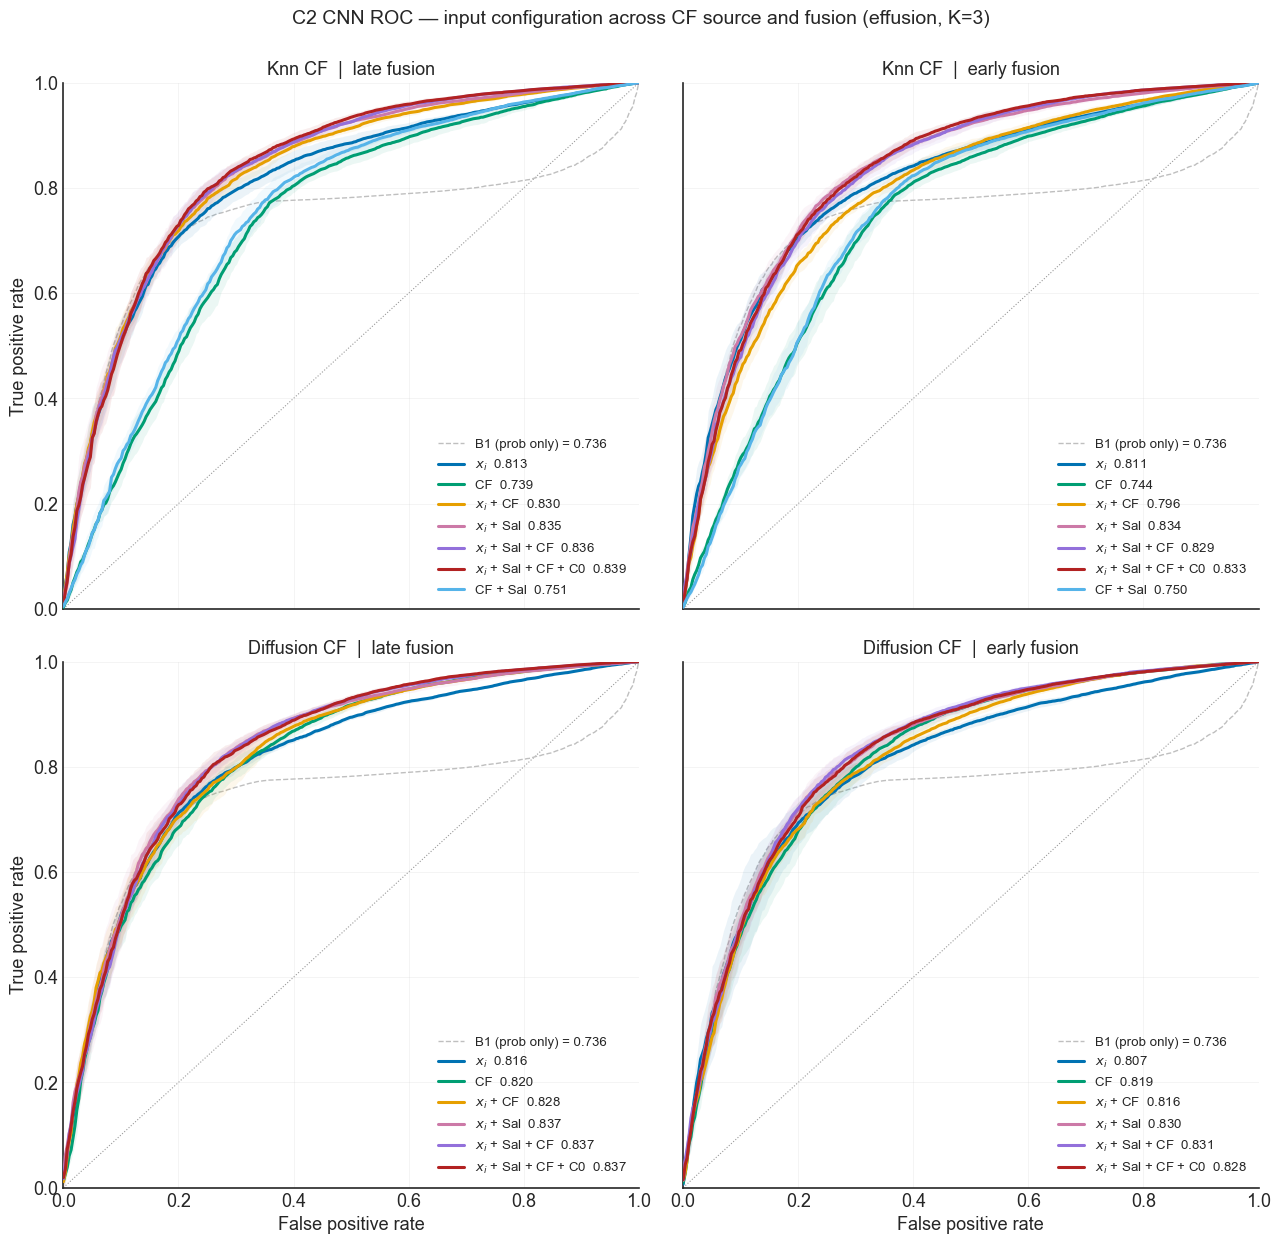

In [11]:
save(plot_roc_grid(K_FOCUS), f'roc_cnn_by_config_{DISEASE}_K{K_FOCUS}')

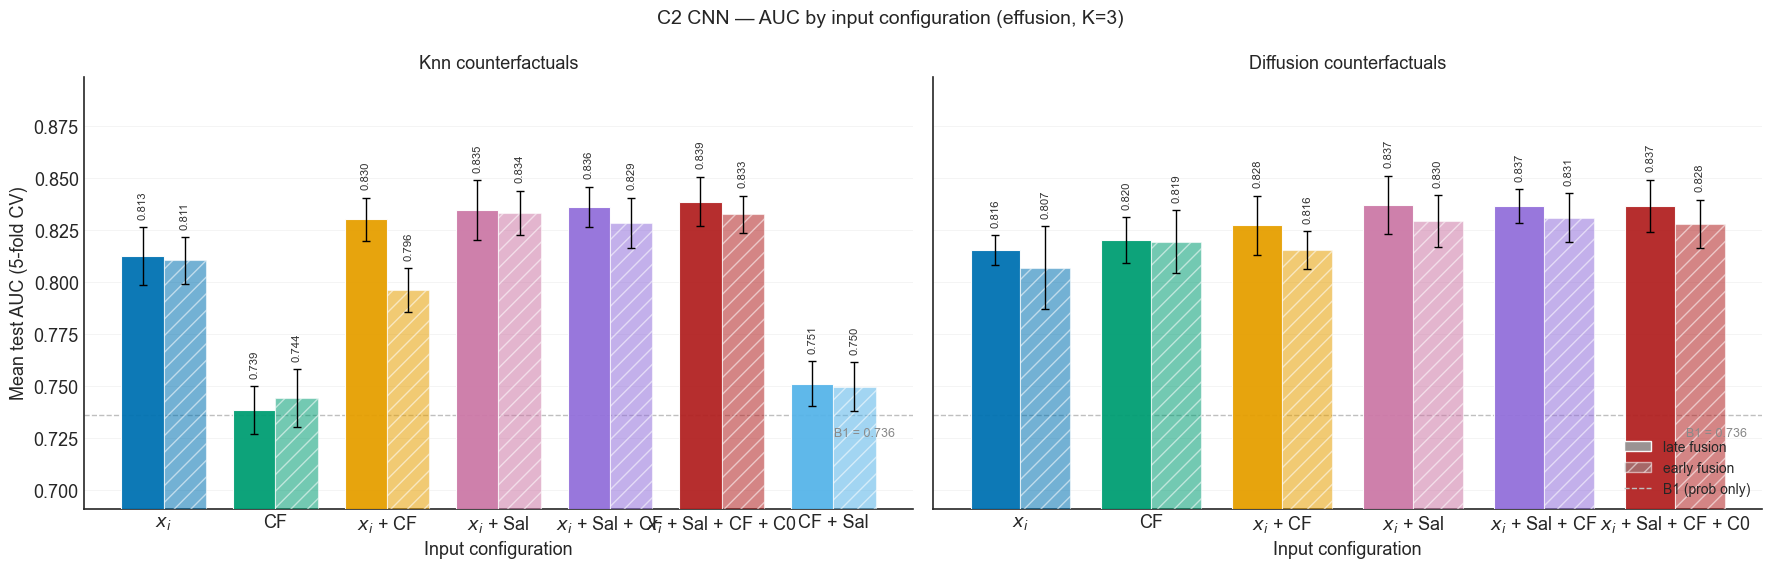

In [19]:
save(plot_auc_bars_by_config(K_FOCUS), f'auc_cnn_by_config_{DISEASE}_K{K_FOCUS}')

---
## 3. Fusion strategy — late vs early

**Late fusion** gives each input its own DenseNet121 and concatenates the pooled embeddings.
**Early fusion** channel-concatenates the inputs into one DenseNet and inflates `conv0` from
3 to *C* channels; because $x_i$, its CF and their Grad-CAMs are pixel-aligned, the first conv
can compare the same spatial location across inputs.

Only `xi+cf` and `xi+sal+cf` push the query image *and* a counterfactual through the same
`conv0`, so those are the slopes to watch.

---
## 5. Number of counterfactuals — does more than one CF help?

Each query is paired with its *K* nearest counterfactuals (kNN) or *K* generated ones
(diffusion); the encoder sees them stacked, so K controls how much counterfactual evidence
the model gets per decision.

`xi` and `xi+sal` never read a counterfactual, so their lines are flat by construction —
they are the controls, drawn faint. Only the CF-consuming configs can respond to K.

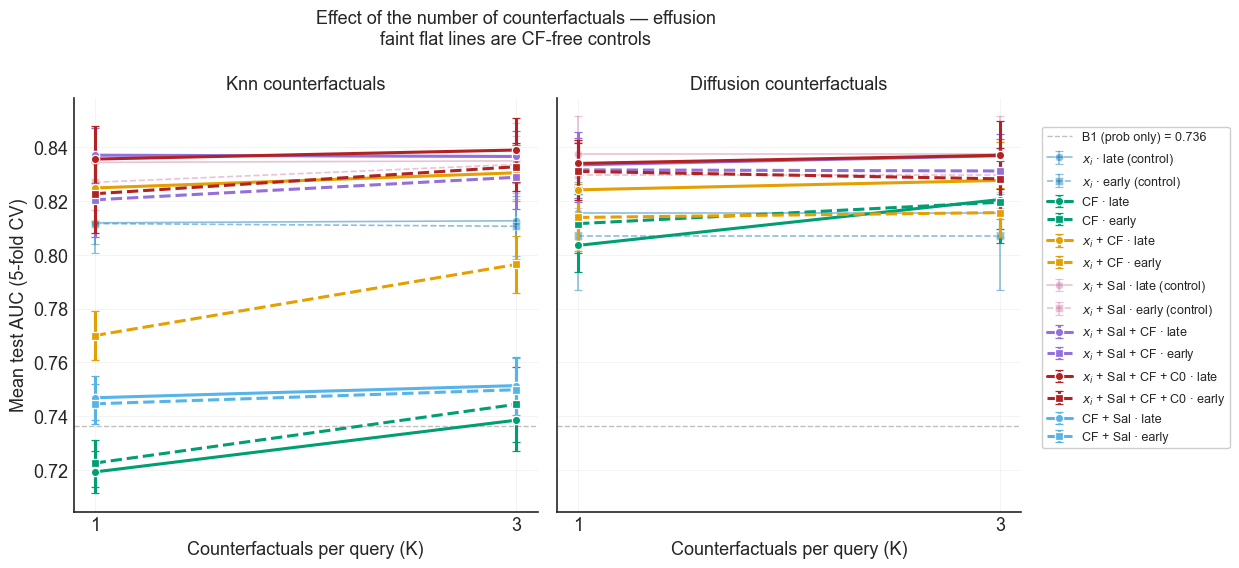

In [13]:
if len(KS) < 2:
    print(f'Only K = {KS} loaded; a trend needs at least two K values.')
else:
    save(plot_auc_vs_k(), f'effect_k_{DISEASE}')

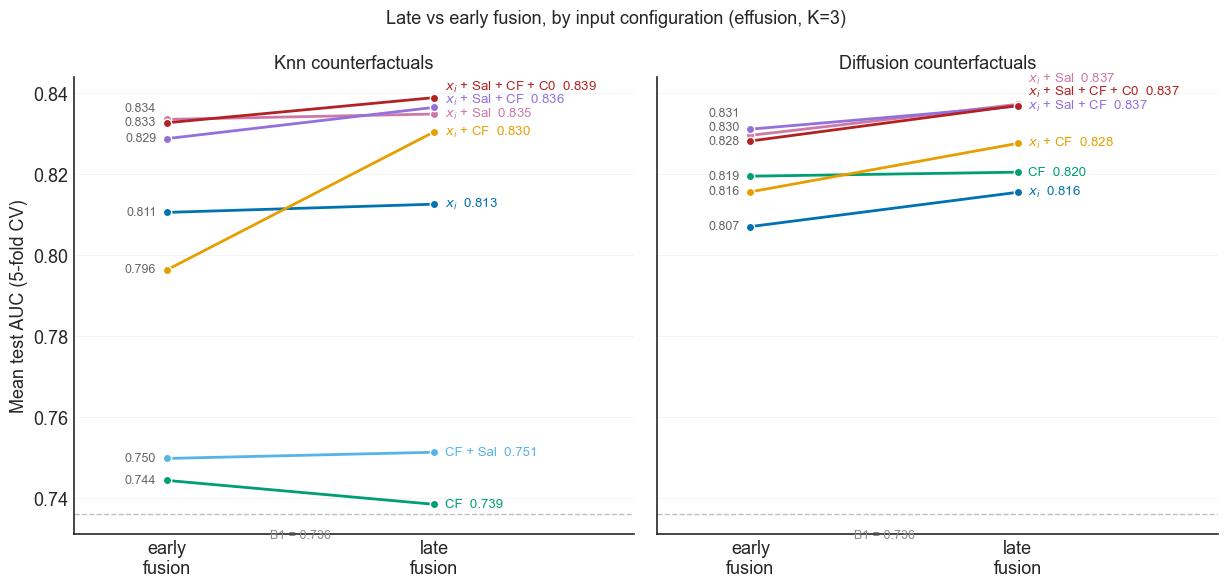

In [23]:
# Plot fusion slopes using plot_fusion_slopes function
save(plot_fusion_slopes(K_FOCUS), f'fusion_slopes_{DISEASE}_K{K_FOCUS}')

---
## 6. All four factors at once

Rows are input configurations, columns are (CF source × fusion × K) cells, with a heavier rule
separating the source/fusion blocks so the K columns read as a group. A **sequential single-hue
ramp** (light → dark = worse → better), because AUC is a magnitude, not an identity. Cell values
are printed, so the encoding never depends on colour alone. A dash is a config that pipeline does
not define, or a run that has not finished.

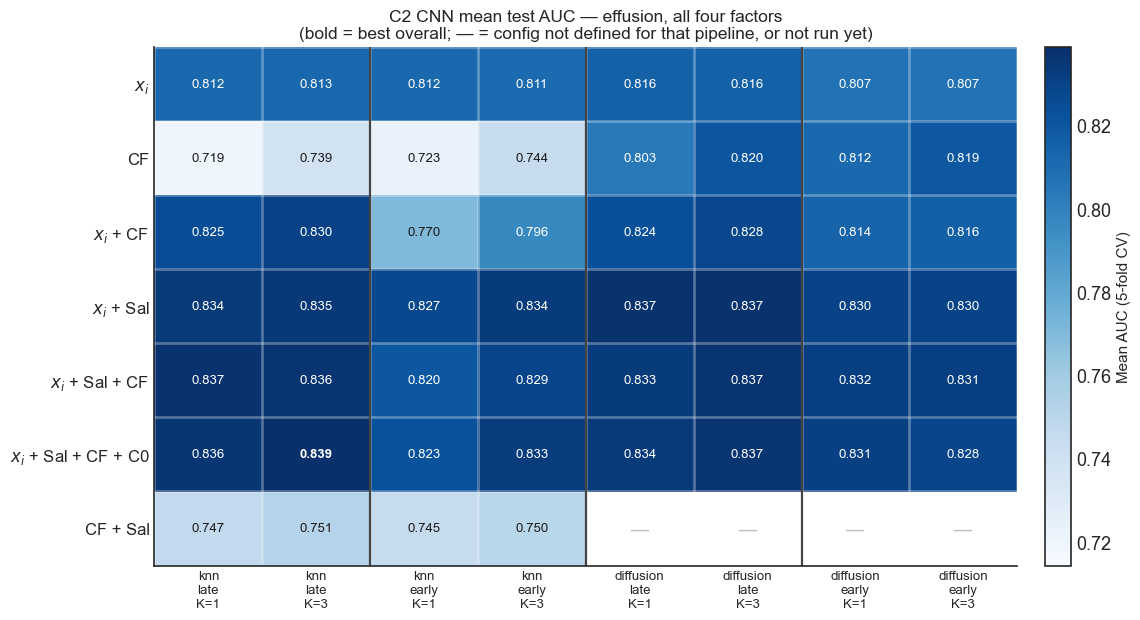

In [20]:
save(plot_heatmap(), f'heatmap_cnn_all_factors_{DISEASE}')

In [21]:
# ── Master summary table -> CSV (every K, not just K_FOCUS) ───────────────────
summary = (pd.DataFrame([
        dict(cf_source=source, fusion=fusion, config=config, K=K,
             auc=run['auc'], auc_std=run['auc_std'],
             n_folds=run['n_folds'], partial=run['partial'],
             fold_aucs=', '.join(f'{a:.4f}' for a in run['aucs']),
             delta_vs_B1=run['auc'] - B1['auc'] if B1 else np.nan)
        for (source, fusion, config, K), run in RUNS.items()])
    .assign(_c=lambda d: d['config'].map({c: i for i, c in enumerate(CONFIG_ORDER)}))
    .sort_values(['cf_source', 'fusion', 'K', '_c'])
    .drop(columns='_c')
    .reset_index(drop=True))

print(f'C2 CNN — all runs, {DISEASE}, K in {KS}')
print('=' * 118)
print(summary.to_string(index=False, formatters={
    'auc': '{:.4f}'.format, 'auc_std': '{:.4f}'.format, 'delta_vs_B1': '{:+.4f}'.format}))

best = summary.loc[summary['auc'].idxmax()]
print(f"\nBest run overall: {best['cf_source']} · {best['fusion']} · {best['config']} "
      f"· K={best['K']} = {best['auc']:.4f} ± {best['auc_std']:.4f}")
focus = summary[summary['K'] == K_FOCUS]
bf = focus.loc[focus['auc'].idxmax()]
print(f"Best run at K={K_FOCUS}:  {bf['cf_source']} · {bf['fusion']} · {bf['config']} "
      f"= {bf['auc']:.4f} ± {bf['auc_std']:.4f}")
if B1 is not None:
    print(f"B1 reference (C0 prob only, LR): {B1['auc']:.4f} ± {B1['auc_std']:.4f}")

path = f'{OUTPUT_DIR}/auc_cnn_all_factors_{DISEASE}.csv'
summary.to_csv(path, index=False)
print(f'\nSaved -> {path}')

C2 CNN — all runs, effusion, K in [1, 3]
cf_source fusion            config  K    auc auc_std  n_folds  partial                              fold_aucs delta_vs_B1
diffusion  early                xi  1 0.8071  0.0201        5    False 0.8094, 0.7838, 0.8269, 0.7844, 0.8307     +0.0708
diffusion  early                cf  1 0.8115  0.0110        5    False 0.8077, 0.7959, 0.8246, 0.8059, 0.8235     +0.0753
diffusion  early             xi+cf  1 0.8138  0.0124        5    False 0.8121, 0.7928, 0.8313, 0.8165, 0.8164     +0.0776
diffusion  early            xi+sal  1 0.8296  0.0124        5    False 0.8397, 0.8081, 0.8378, 0.8230, 0.8392     +0.0933
diffusion  early         xi+sal+cf  1 0.8315  0.0119        5    False 0.8317, 0.8112, 0.8452, 0.8279, 0.8415     +0.0953
diffusion  early xi+sal+cf+scalars  1 0.8309  0.0105        5    False 0.8403, 0.8163, 0.8438, 0.8218, 0.8324     +0.0947
diffusion  early                xi  3 0.8071  0.0201        5    False 0.8094, 0.7838, 0.8269, 0.7844, 0.